# SAC Navigation

In [2]:
import mujoco
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import os, imageio, base64
from collections import deque
from scipy.spatial.transform import Rotation
from IPython.display import display, HTML
from PIL import Image as PILImage, ImageDraw
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import sys
from shared_tracker import RunLogger

# Change this to your own path if needed.
XML_PATH     = "segway_2.xml"
sys.path.append("/Users/kchong99/Documents/Master/ME 569/owsbr/Arthur/Ozzy_Segway_Data")



SAVE_DIR     = "SavedSeeds"
TRAIN_SEEDS  = [42]
VERIFY_SEEDS = [788, 999, 555, 321, 444]
os.makedirs(SAVE_DIR, exist_ok=True)

ModuleNotFoundError: No module named 'shared_tracker'

## Segway starts from the ground

In [ ]:
def get_ground_contact_z(xml_path, tilt=0.0):
    """Find the correct z so the segway sits ON the ground at given tilt."""
    model = mujoco.MjModel.from_xml_path(xml_path)
    data  = mujoco.MjData(model)
    mujoco.mj_resetData(model, data)
    rot  = Rotation.from_euler('y', tilt)
    quat = rot.as_quat()
    data.qpos[3:7] = [quat[3], quat[0], quat[1], quat[2]]
    data.qpos[2]   = 2.0
    data.qvel[:]   = 0.0
    mujoco.mj_forward(model, data)
    for _ in range(2000):
        data.ctrl[:] = 0.0
        mujoco.mj_step(model, data)
        if abs(data.qvel[2]) < 0.001 and data.qpos[2] < 0.5:
            break
    return data.qpos[2]

print("Building ground contact lookup table...")
GROUND_Z_TABLE = {}
for tilt in np.arange(0.0, 1.1, 0.05):
    GROUND_Z_TABLE[round(tilt, 2)]  = get_ground_contact_z(XML_PATH, tilt)
    GROUND_Z_TABLE[round(-tilt, 2)] = GROUND_Z_TABLE[round(tilt, 2)]
print("Done.")

def get_z_for_tilt(tilt):
    key = round(round(abs(tilt) / 0.05) * 0.05, 2)
    return GROUND_Z_TABLE.get(min(key, 1.0), GROUND_Z_TABLE[0.0])

Building ground contact lookup table...


ValueError: ParseXML: Error opening file 'segway_2.xml'

## Observation helpers

In [ ]:
def get_obs(data):
    quat  = data.qpos[3:7]
    rot   = Rotation.from_quat([quat[1], quat[2], quat[3], quat[0]])
    theta = rot.as_euler('xyz')[1]
    return np.array([data.qpos[0], data.qvel[0], theta, data.qvel[4]], dtype=np.float32)

def normalize_obs(obs):
    x, xd, th, thd = obs
    return np.array([
        np.clip(x   / 2.4,  -1, 1),
        np.clip(xd  / 5.0,  -1, 1),
        np.clip(th  / 1.57, -1, 1),
        np.clip(thd / 5.0,  -1, 1),
    ], dtype=np.float32)

## Reward function

In [ ]:
def nav_reward(obs, prev_x, goal_x, at_goal, done, step):
    x, xd, theta, thd = obs
    if done:    return -20.0
    if at_goal: return  50.0
    r  = (abs(prev_x - goal_x) - abs(x - goal_x)) * 15.0
    r -= abs(x - goal_x) * 0.05
    r += 0.02
    if abs(theta) > 0.20:
        r -= (abs(theta) - 0.2) * 5.0
    return float(r)

## SAC Networks

### Key differences from PPO's `NavPPO`:

| PPO `NavPPO` | SAC `NavActor` | Why |
|---|---|---|
| Shared trunk → actor + critic heads | Separate `NavActor` and `NavCritic` classes | SAC uses off-policy critics; coupling wastes capacity |
| `actor_log_std` is a single **learned parameter** | `log_std` is a **network output** (state-dependent) | SAC benefits from input-dependent uncertainty |
| One critic head | **Twin Q-networks** (Q1 + Q2) | Prevents Q-value overestimation |
| No target network | **`critic_tgt`** with soft update τ=0.005 | Off-policy TD needs stable targets |
| Fixed entropy weight ENT | **Learnable `log_alpha`** (auto-tuned) | Maintains target entropy automatically |

In [ ]:
class NavActor(nn.Module):
    """
    Squashed Gaussian actor.
    Input : 5-dim (4 normalised obs + goal distance)
    Output: torque in (-torque_max, torque_max) via tanh
    Signature of get_action() is identical to PPO NavPPO — drop-in compatible.
    """
    LOG_STD_MIN = -5
    LOG_STD_MAX =  2

    def __init__(self, torque_max=5.0):
        super().__init__()
        self.torque_max = torque_max
        self.net = nn.Sequential(
            nn.Linear(5, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
        )
        self.mean_layer    = nn.Linear(256, 1)
        self.log_std_layer = nn.Linear(256, 1)  # state-dependent std (unlike PPO's fixed param)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, 0.5)
                nn.init.zeros_(m.bias)
        nn.init.orthogonal_(self.mean_layer.weight, 0.01)

    def forward(self, x):
        h = self.net(x)
        mean    = self.mean_layer(h)
        log_std = self.log_std_layer(h).clamp(self.LOG_STD_MIN, self.LOG_STD_MAX)
        return mean, log_std.exp()

    def get_action(self, obs, goal_x, deterministic=False):
        """
        Same signature as PPO NavPPO.get_action.
        Returns (torque, log_prob, None)  — None replaces PPO's value estimate.
        """
        dist_norm = float(np.clip((goal_x - obs[0]) / 5., -1, 1))
        inp = torch.FloatTensor([*normalize_obs(obs), dist_norm]).unsqueeze(0)
        with torch.no_grad():
            mean, std = self(inp)
            if deterministic:
                raw  = mean
                logp = torch.zeros(1)
            else:
                dist = torch.distributions.Normal(mean, std)
                raw  = dist.rsample()
                # tanh squashing correction to log prob
                logp = (dist.log_prob(raw)
                        - torch.log(1 - torch.tanh(raw).pow(2) + 1e-6)).sum(-1)
            torque = torch.tanh(raw) * self.torque_max
        return torque.item(), logp, None

    def sample(self, obs_t):
        """Batched reparameterised sample used inside SAC update."""
        mean, std = self(obs_t)
        dist  = torch.distributions.Normal(mean, std)
        raw   = dist.rsample()
        logp  = (dist.log_prob(raw)
                 - torch.log(1 - torch.tanh(raw).pow(2) + 1e-6)).sum(-1, keepdim=True)
        torque = torch.tanh(raw) * self.torque_max
        return torque, logp, torch.tanh(mean) * self.torque_max


class NavCritic(nn.Module):
    """
    Twin Q-networks Q1 and Q2.
    Input : 5-dim obs + 1-dim action = 6 total
    Output: scalar Q-value from both heads
    Using two independent heads reduces overestimation (Fujimoto et al. 2018).
    """
    def __init__(self):
        super().__init__()
        def make_q():
            return nn.Sequential(
                nn.Linear(6, 256), nn.ReLU(),
                nn.Linear(256, 256), nn.ReLU(),
                nn.Linear(256, 1),
            )
        self.q1, self.q2 = make_q(), make_q()
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, 0.5)
                nn.init.zeros_(m.bias)

    def forward(self, obs_t, act_t):
        x = torch.cat([obs_t, act_t], dim=-1)
        return self.q1(x), self.q2(x)

## Replay Buffer

In [ ]:
class ReplayBuffer:
    """
    Off-policy replay buffer.
    Stores normalised 5-dim inputs (not raw obs) so no re-computation at sample time.
    """
    def __init__(self, capacity=1_000_000, obs_dim=5):
        self.cap  = capacity
        self.ptr  = self.size = 0
        self.obs  = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.act  = np.zeros((capacity, 1),       dtype=np.float32)
        self.rew  = np.zeros((capacity, 1),       dtype=np.float32)
        self.obs2 = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.done = np.zeros((capacity, 1),       dtype=np.float32)

    def push(self, o, a, r, o2, d):
        self.obs [self.ptr] = o
        self.act [self.ptr] = [a]
        self.rew [self.ptr] = r
        self.obs2[self.ptr] = o2
        self.done[self.ptr] = d
        self.ptr  = (self.ptr + 1) % self.cap
        self.size = min(self.size + 1, self.cap)

    def sample(self, n=256):
        i = np.random.randint(0, self.size, n)
        return (torch.FloatTensor(self.obs [i]),
                torch.FloatTensor(self.act [i]),
                torch.FloatTensor(self.rew [i]),
                torch.FloatTensor(self.obs2[i]),
                torch.FloatTensor(self.done[i]))

    def __len__(self):
        return self.size

## SAC `train_nav`  ← **NEW** (replaces PPO `train_nav`)

Same function name and signature — `run_nav_multi_seed` calls it with no changes.

### SAC update equations inside `sac_update()`:

```
Critic:   y = r + γ(1-d)[min(Q1_tgt, Q2_tgt)(s', a') - α log π(a'|s')]
          L_Q = MSE(Q1, y) + MSE(Q2, y)

Actor:    L_π = E[α log π(a|s) - min(Q1, Q2)(s, a)]

Alpha:    L_α = E[-log_α (log π(a|s) + H_target)]

Targets:  θ_tgt ← (1-τ) θ_tgt + τ θ      (soft update, τ=0.005)
```

In [ ]:
# ==========================================================================
# SAC  —  instrumented train_nav.
# Replace your existing SAC train_nav with this. Changes are marked  # <-- NEW
# Key change: stop on STEP BUDGET (fair), not on max_episodes.
# ==========================================================================
def train_nav(x_start=0.0, x_goal=2.0,
              seed=42, tag="nav_sac_v1",
              max_steps=3000000):              # <-- NEW: step budget, not episodes
    torch.manual_seed(seed); np.random.seed(seed)

    GAMMA, TAU, LR = 0.99, 0.005, 3e-4
    BATCH, WARMUP, MAX_EP_STEPS = 256, 5000, 3000
    TARGET_ENT = -1.0

    actor      = NavActor(torque_max=5.0)
    critic     = NavCritic()
    critic_tgt = NavCritic(); critic_tgt.load_state_dict(critic.state_dict())
    for p in critic_tgt.parameters(): p.requires_grad = False
    actor_opt  = optim.Adam(actor.parameters(),  lr=LR)
    critic_opt = optim.Adam(critic.parameters(), lr=LR)
    log_alpha  = torch.tensor(0.0, requires_grad=True)
    alpha_opt  = optim.Adam([log_alpha], lr=LR)
    replay = ReplayBuffer(1_000_000, obs_dim=5)

    model = mujoco.MjModel.from_xml_path(XML_PATH)
    data  = mujoco.MjData(model)

    def reset_env():
        mujoco.mj_resetData(model, data)
        data.qpos[0]=x_start; data.qpos[1]=0.0
        data.qpos[2]=get_z_for_tilt(0.0); data.qpos[3:7]=[1,0,0,0]
        data.qvel[:]=0.0; data.qvel[4]=np.random.uniform(-0.01,0.01)
        mujoco.mj_forward(model, data); return get_obs(data)

    def env_step(torque):
        u=float(np.clip(torque,-5.,5.)); data.ctrl[0]=-u; data.ctrl[1]=0.0
        mujoco.mj_step(model,data); obs=get_obs(data); x,_,th,_=obs
        return obs, (abs(x)>2.8 or abs(th)>0.5), (abs(x-x_goal)<0.10 and abs(th)<0.25)

    def make_inp(obs):
        return np.array([*normalize_obs(obs),
                         float(np.clip((x_goal-obs[0])/5.,-1,1))], dtype=np.float32)

    def sac_update():
        if len(replay) < BATCH: return 0.0
        ob,ac,re,ob2,dn = replay.sample(BATCH)
        alpha = log_alpha.exp().detach()
        with torch.no_grad():
            na,nlp,_ = actor.sample(ob2)
            qt = torch.min(*critic_tgt(ob2,na)) - alpha*nlp
            y  = re + GAMMA*(1-dn)*qt
        q1,q2 = critic(ob,ac)
        cl = nn.MSELoss()(q1,y) + nn.MSELoss()(q2,y)
        critic_opt.zero_grad(); cl.backward()
        nn.utils.clip_grad_norm_(critic.parameters(),1.0); critic_opt.step()
        na,lp,_ = actor.sample(ob)
        al = (alpha*lp - torch.min(*critic(ob,na))).mean()
        actor_opt.zero_grad(); al.backward()
        nn.utils.clip_grad_norm_(actor.parameters(),1.0); actor_opt.step()
        eal = -(log_alpha*(lp+TARGET_ENT).detach()).mean()
        alpha_opt.zero_grad(); eal.backward(); alpha_opt.step()
        with torch.no_grad():
            for p,pt in zip(critic.parameters(),critic_tgt.parameters()):
                pt.data.mul_(1-TAU); pt.data.add_(TAU*p.data)
        return cl.item()

    logger = RunLogger("SAC", seed, log_every_steps=2000)   # <-- NEW
    rewards=[]; losses=[]; best_avg=-9999; best_weights=None
    total_steps = ep_count = 0

    print(f"\nSAC | A={x_start}m -> B={x_goal}m | budget={max_steps:,} steps")
    print(f"{'Steps':>9} | {'Ep':>5} | {'Avg100':>8} | {'Rec%':>6} | {'Alpha':>7} | {'CritL':>8}")
    print("-"*64)

    while total_steps < max_steps:                          # <-- NEW: step budget
        obs=reset_env(); ep_ret=0.0; prev_x=obs[0]; ep_step=0; ep_cls=[]
        arrived_flag = False
        for _ in range(MAX_EP_STEPS):
            torque = (np.random.uniform(-5.,5.) if total_steps < WARMUP
                      else actor.get_action(obs, x_goal)[0])
            obs2,done,at_goal = env_step(torque)
            ep_step+=1; total_steps+=1
            r=nav_reward(obs2,prev_x,x_goal,at_goal,done,ep_step)
            ep_ret+=r; prev_x=obs2[0]
            replay.push(make_inp(obs),torque,r,make_inp(obs2),float(done or at_goal))
            if total_steps>=WARMUP: ep_cls.append(sac_update())
            obs=obs2
            if done or at_goal or ep_step>=MAX_EP_STEPS:
                arrived_flag = at_goal
                break
            if total_steps>=max_steps: break

        ep_count+=1
        ep_loss = float(np.mean(ep_cls)) if ep_cls else 0.0
        rewards.append(ep_ret); losses.append(ep_loss)

        # <-- NEW: single logging call, identical to PPO's
        avg, rp = logger.episode_end(total_steps, ep_count, ep_ret, arrived_flag, ep_loss)

        if ep_count % 50 == 0:
            al=float(log_alpha.exp().item())
            icon="✅" if avg>0 else "🔄" if avg>-20 else "⏳"
            print(f"{total_steps:>9,} | {ep_count:>5} | {avg:>8.2f} | "
                  f"{rp:>5.1f}% | {al:>7.4f} | {ep_loss:>8.3f} {icon}", flush=True)
            if avg>best_avg:
                best_avg=avg
                best_weights={k:v.clone() for k,v in actor.state_dict().items()}
                torch.save(actor.state_dict(), f"{SAVE_DIR}/nav_sac_{tag}.pth")

    if best_weights: actor.load_state_dict(best_weights)
    return actor, rewards, losses, logger          # <-- NEW: also return logger

In [ ]:
def train_one_verify_many(algo_label,
                          train_seed   = 42,
                          verify_seeds = (788, 999, 555, 321, 444,
                                          123, 777, 256, 512, 111),
                          x_start=0.0, x_goal=2.0,
                          step_budget=500_000):
    verify_seeds = list(verify_seeds)

    # ---- 1. TRAIN on the single train_seed ----
    print(f"\n{'='*60}\n  {algo_label}  TRAIN seed = {train_seed}\n{'='*60}")
    net, rewards, losses, logger = train_nav(
        x_start=x_start, x_goal=x_goal,
        seed=train_seed, tag=f"cmp_seed{train_seed}",
        max_steps=step_budget)

    # ---- 2. eval helper (deterministic) ----
    def eval_policy(net, seed, n=20):
        torch.manual_seed(seed); np.random.seed(seed)
        model=mujoco.MjModel.from_xml_path(XML_PATH); data=mujoco.MjData(model)
        strict=loose=fell=0; max_xs=[]; times=[]
        for _ in range(n):
            mujoco.mj_resetData(model,data)
            data.qpos[0]=x_start; data.qpos[2]=get_z_for_tilt(0.0)
            data.qpos[3:7]=[1,0,0,0]; data.qvel[:]=0.0
            data.qvel[4]=np.random.uniform(-0.02,0.02)
            mujoco.mj_forward(model,data); obs=get_obs(data); mx=0.0; end="timeout"
            for step in range(3000):
                with torch.no_grad():
                    t,_,_=net.get_action(obs,x_goal,deterministic=True)
                data.ctrl[0]=-float(np.clip(t,-5,5)); data.ctrl[1]=0.0
                mujoco.mj_step(model,data); obs=get_obs(data); x,_,th,_=obs
                mx=max(mx,x)
                if abs(x)>2.8 or abs(th)>0.5: end="fell"; break
                if abs(x-x_goal)<0.10 and abs(th)<0.35:
                    end="strict"; times.append(step*model.opt.timestep); break
                elif abs(x-x_goal)<0.25 and abs(th)<0.35:
                    end="loose"; times.append(step*model.opt.timestep)
            strict+=end=="strict"; loose+=end=="loose"; fell+=end=="fell"
            max_xs.append(mx)
        return {"strict_pct":strict/n*100,"loose_pct":(strict+loose)/n*100,
                "fell_pct":fell/n*100,"avg_max_x":float(np.mean(max_xs)),
                "avg_time":float(np.mean(times)) if times else 999.0}

    # ---- 3. VERIFY the one policy on every verify seed ----
    print(f"\n  Verifying {algo_label} policy (trained on {train_seed}) "
          f"on {len(verify_seeds)} unseen seeds:")
    print(f"  {'Seed':>6} | {'Strict%':>8} | {'Loose%':>7} | {'Fell%':>6} | {'Time':>6}")
    print("  " + "-"*48)
    per_seed={}
    for vs in verify_seeds:
        r=eval_policy(net, vs); per_seed[vs]=r
        icon="✅" if r["strict_pct"]>=80 else "🔄" if r["strict_pct"]>=50 else "❌"
        print(f"  {vs:>6} | {r['strict_pct']:>7.0f}% | {r['loose_pct']:>6.0f}% | "
              f"{r['fell_pct']:>5.0f}% | {r['avg_time']:>5.1f}s {icon}")

    # ---- 4. aggregate across verify seeds ----
    summary={
        "train_seed":   train_seed,
        "verify_seeds": verify_seeds,
        "strict_pct":   float(np.mean([per_seed[v]["strict_pct"] for v in verify_seeds])),
        "strict_std":   float(np.std ([per_seed[v]["strict_pct"] for v in verify_seeds])),
        "fell_pct":     float(np.mean([per_seed[v]["fell_pct"]   for v in verify_seeds])),
        "avg_time":     float(np.mean([per_seed[v]["avg_time"]
                                       for v in verify_seeds
                                       if per_seed[v]["avg_time"]<999] or [999])),
        "per_seed":     per_seed,
    }
    print(f"\n  {algo_label} verify avg: "
          f"{summary['strict_pct']:.1f}% ± {summary['strict_std']:.1f}%  strict  |  "
          f"{summary['fell_pct']:.1f}% fell")

    # ---- 5. save the log (this is the JSON you plot from) ----
    logger.save(SAVE_DIR, f"cmp_seed{train_seed}", eval_results=summary)
    return net, logger, summary

# SAC notebook:   train_one_verify_many("SAC", train_seed=42)
# PPO notebook:    train_one_verify_many("PPO", train_seed=42)

# compare()

## Recording Function

In [ ]:
def record_all_seeds(nav_net,
                     train_seeds=[42],
                     verify_seeds=[788,999,555,321,444],
                     x_start=0.0, x_goal=2.0,
                     max_steps=3000):
    model    = mujoco.MjModel.from_xml_path(XML_PATH)
    data     = mujoco.MjData(model)
    dt       = model.opt.timestep
    renderer = mujoco.Renderer(model, height=480, width=640)
    cam=mujoco.MjvCamera(); cam.type=mujoco.mjtCamera.mjCAMERA_FREE
    cam.lookat=np.array([1.0,0.0,0.3]); cam.distance=4.5
    cam.azimuth=90; cam.elevation=-15
    PX_A=160; PX_B=480
    def world_to_px(wx): return int(PX_A+(wx/x_goal)*(PX_B-PX_A))
    all_seeds=[(s,"TRAIN") for s in train_seeds]+[(s,"VERIFY") for s in verify_seeds]
    print("Recording seeds...")
    for seed,role in all_seeds:
        torch.manual_seed(seed); np.random.seed(seed)
        mujoco.mj_resetData(model,data)
        data.qpos[0]=x_start; data.qpos[1]=0.0
        data.qpos[2]=get_z_for_tilt(0.0); data.qpos[3:7]=[1,0,0,0]
        data.qvel[:]=0.0; mujoco.mj_forward(model,data)
        obs=get_obs(data); frames=[]; strict=arrived=fell=False
        for step in range(max_steps):
            with torch.no_grad():
                torque,_,_ = nav_net.get_action(obs,x_goal,deterministic=True)
            data.ctrl[0]=-float(np.clip(torque,-5,5)); data.ctrl[1]=0.0
            mujoco.mj_step(model,data); obs=get_obs(data); x,_,theta,_=obs
            fell=abs(x)>2.8 or abs(theta)>0.5
            arrived=abs(x-x_goal)<0.25 and abs(theta)<0.35
            strict=abs(x-x_goal)<0.10 and abs(theta)<0.35
            renderer.update_scene(data,camera=cam)
            img=PILImage.fromarray(renderer.render()); draw=ImageDraw.Draw(img); W,H=img.size
            prog=float(np.clip(x/x_goal,0,1)); bw=W-40
            pcol=(0,200,0) if strict else (255,140,0) if arrived else (30,100,220)
            draw.rectangle([20,8,W-20,28],fill=(40,40,40))
            draw.rectangle([20,8,20+int(bw*prog),28],fill=pcol)
            draw.text((22,10),"A",fill=(255,255,255)); draw.text((W-28,10),"B",fill=(255,255,255))
            draw.text((W//2-40,10),f"{prog*100:.0f}%  x={x:.3f}m",fill=(255,255,255))
            badge_col=(0,60,140) if role=="TRAIN" else (100,0,140)
            draw.rectangle([8,34,170,58],fill=badge_col)
            draw.text((12,38),f"[{role}] seed={seed}",fill=(255,255,255))
            if strict:   sc=(0,120,0);   st=f"✓ STRICT  x={x:.3f}m  t={step*dt:.1f}s"
            elif arrived:sc=(120,100,0); st=f"~ LOOSE   x={x:.3f}m  t={step*dt:.1f}s"
            elif fell:   sc=(140,0,0);   st=f"✗ FELL    x={x:.3f}m  θ={np.degrees(theta):.1f}°"
            else:        sc=(20,20,70);  st=f"x={x:+.3f}m  θ={np.degrees(theta):+.1f}°  u={torque:+.1f}Nm  t={step*dt:.1f}s"
            draw.rectangle([175,34,W-8,58],fill=sc); draw.text((178,38),st,fill=(255,255,255))
            my=H-55
            a_px=world_to_px(x_start); b_px=world_to_px(x_goal)
            s_px=world_to_px(float(np.clip(x,-0.3,2.5)))
            draw.line([(a_px-5,my+15),(b_px+5,my+15)],fill=(180,180,180),width=3)
            draw.ellipse([a_px-14,my+4,a_px+14,my+26],fill=(50,100,220),outline=(255,255,255),width=2)
            draw.text((a_px-5,my+8),"A",fill=(255,255,255))
            draw.ellipse([b_px-14,my+4,b_px+14,my+26],fill=(0,180,70),outline=(255,255,255),width=2)
            draw.text((b_px-5,my+8),"B",fill=(255,255,255))
            scol=(0,220,100) if strict else (255,210,0)
            draw.ellipse([s_px-9,my+7,s_px+9,my+23],fill=scol,outline=(255,255,255),width=2)
            frames.append(np.array(img))
            if strict or fell: frames+=[frames[-1]]*60; break
        result="STRICT" if strict else "FELL" if fell else f"LOOSE@{x:.2f}m"
        print(f"  [{role}] seed={seed}: {result}")
        fname=f"nav_sac_{role.lower()}_seed{seed}.mp4"
        imageio.mimsave(fname,frames,fps=30)
        sz=os.path.getsize(fname)//1024; print(f"    saved {fname} ({sz} KB)")
        b64=base64.b64encode(open(fname,"rb").read()).decode()
        display(HTML(f'<b>[{role}] Seed {seed} — {result}</b><br>'
                     f'<video width="640" height="480" controls autoplay loop>'
                     f'<source src="data:video/mp4;base64,{b64}" type="video/mp4"></video>'))
    print("\nDone.")

## Plot Episode Traces

In [ ]:
def plot_episode_traces(net, algo="model", x_goal=2.0, save_prefix=None):
    save_prefix = save_prefix or algo.lower()

    model = mujoco.MjModel.from_xml_path(XML_PATH)
    data  = mujoco.MjData(model)
    dt    = model.opt.timestep
    mujoco.mj_resetData(model, data)
    data.qpos[0]=0.0; data.qpos[2]=get_z_for_tilt(0.0)
    data.qpos[3:7]=[1,0,0,0]; data.qvel[:]=0.0
    mujoco.mj_forward(model, data)
    obs=get_obs(data)
    ts,xs,ths,torqs=[],[],[],[]
    prev_x=0.0

    for step in range(3000):
        with torch.no_grad():
            torque,_,_ = net.get_action(obs, x_goal, deterministic=True)
        u=float(np.clip(torque,-5,5)); data.ctrl[0]=-u; data.ctrl[1]=0.0
        mujoco.mj_step(model,data); obs=get_obs(data); x,xd,th,thd=obs
        ts.append(step*dt); xs.append(x); ths.append(np.degrees(th)); torqs.append(torque)
        prev_x=x
        if abs(x)>2.8 or abs(th)>0.5 or (abs(x-x_goal)<0.25 and abs(th)<0.35):
            break

    ts=np.array(ts); xs=np.array(xs); ths=np.array(ths); torqs=np.array(torqs)
    arrived = abs(xs[-1]-x_goal)<0.25 and abs(ths[-1])<20
    rms=np.sqrt(np.mean(torqs**2)); sat=np.abs(torqs)>4.8

    # 2x2 grid: position spans the top row, tilt + torque on the bottom
    fig=plt.figure(figsize=(15,9))
    gs=gridspec.GridSpec(2,2,hspace=0.38,wspace=0.25,figure=fig)
    fig.suptitle(f"{algo} — Deterministic Episode Behaviour",
                 fontsize=13, fontweight="bold")

    # position (spans top)
    ax=fig.add_subplot(gs[0,:])
    ax.plot(ts,xs,"#E74C3C",lw=2.5,label="x position")
    ax.axhline(0,color="blue",ls=":",lw=2,label="A (start)")
    ax.axhline(x_goal,color="green",ls=":",lw=2,label=f"B (goal={x_goal}m)")
    ax.axhspan(x_goal-0.25,x_goal+0.25,alpha=0.1,color="green",label="Goal zone ±0.25m")
    if arrived:
        idx=np.where(np.abs(xs-x_goal)<0.25)[0][0]
        ax.axvline(ts[idx],color="green",ls="--",alpha=0.6)
        ax.annotate(f"ARRIVED\nt={ts[idx]:.1f}s",xy=(ts[idx],xs[idx]),
                    xytext=(ts[idx]+0.2,x_goal-0.3),color="green",fontsize=9,
                    arrowprops=dict(arrowstyle="->",color="green"))
    ax.set_xlabel("Time (s)"); ax.set_ylabel("Position x (m)")
    ax.set_title("Position: A → B",fontweight="bold")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    # tilt (bottom-left)
    ax=fig.add_subplot(gs[1,0])
    ax.plot(ts,ths,"#E74C3C",lw=2,label="θ (degrees)")
    ax.axhspan(-20,20,alpha=0.06,color="green",label="Stable ±20°")
    ax.axhline(0,color="gray",alpha=0.4)
    ax.set_xlabel("Time (s)"); ax.set_ylabel("Tilt Angle (°)")
    ax.set_title("Tilt Angle θ",fontweight="bold")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    # torque (bottom-right)
    ax=fig.add_subplot(gs[1,1])
    ax.plot(ts,torqs,"#2ECC71",lw=2,label="Torque (Nm)")
    ax.fill_between(ts,torqs,0,where=(torqs>0),alpha=0.15,color="red",label="Forward")
    ax.fill_between(ts,torqs,0,where=(torqs<0),alpha=0.15,color="blue",label="Backward")
    ax.axhline(5,color="orange",ls=":",lw=1.5,label="Motor limit ±5Nm")
    ax.axhline(-5,color="orange",ls=":",lw=1.5)
    ax.axhline(0,color="gray",alpha=0.4)
    if sat.any():
        ax.fill_between(ts,-5,5,where=sat,alpha=0.15,color="red",label="Saturated!")
    ax.set_xlabel("Time (s)"); ax.set_ylabel("Torque (Nm)")
    ax.set_title(f"Motor Torque  (RMS={rms:.2f} Nm)",fontweight="bold")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    plt.savefig(f"{save_prefix}_episode_traces.png",dpi=150,bbox_inches="tight")
    plt.show(); print(f"Saved: {save_prefix}_episode_traces.png")

    print(f"\n{'='*55}\n  {algo} Episode Summary\n{'='*55}")
    print(f"  Duration   : {ts[-1]:.1f}s  ({len(ts)} steps)")
    print(f"  Max x      : {max(xs):.3f}m  / {x_goal}m")
    print(f"  Final x    : {xs[-1]:.3f}m")
    print(f"  Avg tilt   : {np.mean(np.abs(ths)):.1f}°")
    print(f"  Max tilt   : {max(np.abs(ths)):.1f}°")
    print(f"  Torque RMS : {rms:.3f} Nm")
    print(f"  Saturated  : {sat.sum()} / {len(ts)} steps ({sat.mean()*100:.0f}%)")
    print(f"{'='*55}")

    return {"max_x":float(max(xs)),"final_x":float(xs[-1]),
            "avg_tilt":float(np.mean(np.abs(ths))),"torque_rms":float(rms),
            "arrived":bool(arrived),"duration_s":float(ts[-1])}

## Plot loss and reward function

In [ ]:
# ==========================================================================
# plot_loss_reward  —  per-model, reward + loss as a 1x2 figure.
# BOTH panels now use ENVIRONMENT STEPS on the x-axis (apples-to-apples).
# Works for PPO or SAC.
#   (a) logger:     plot_loss_reward(logger=logger, algo="SAC")
#   (b) raw arrays: plot_loss_reward(rewards=rews, losses=losses, algo="PPO")
#       -> raw-array mode has no step info, so it falls back to index x-axis.
# Total training (wall) time is annotated when a logger is given.
# ==========================================================================
import numpy as np
import matplotlib.pyplot as plt

def plot_loss_reward(logger=None, rewards=None, losses=None,
                     algo="model", save_prefix=None):
    save_prefix = save_prefix or algo.lower()

    wall_time = None
    if logger is not None:
        steps_ts  = [r["steps"]      for r in logger.rows]
        reward_ts = [r["avg_reward"] for r in logger.rows]   # rolling mean on step grid
        loss_ts   = [r["loss"]       for r in logger.rows]
        wall_time = getattr(logger, "total_wall_time", None)
        if wall_time is None and logger.rows:
            wall_time = logger.rows[-1].get("wall_time")
        have_steps = True
    else:
        if rewards is None or losses is None:
            raise ValueError("Pass either logger=, or both rewards= and losses=")
        have_steps = False

    fig, (axr, axl) = plt.subplots(1, 2, figsize=(15, 5))
    title = f"{algo} — Training"
    if wall_time is not None:
        title += f"   (wall time: {wall_time/60:.1f} min)"
    fig.suptitle(title, fontsize=13, fontweight="bold")

    # ---- LEFT: reward vs STEPS ----
    if have_steps:
        x = np.array(steps_ts); y = np.array(reward_ts)
        axr.plot(x, y, color="#E74C3C", lw=2.5,
                 label=f"avg reward (peak={y.max():.1f})")
        axr.set_xlabel("Environment steps")
    else:
        # fallback: no step info in raw arrays, plot vs episode index
        r_arr = np.array(rewards)
        w = min(100, max(2, len(r_arr)//10))
        roll = np.convolve(r_arr, np.ones(w)/w, mode='valid')
        axr.plot(np.arange(len(r_arr)), r_arr, color="#3498DB", alpha=0.2, lw=0.6,
                 label="per-episode")
        axr.plot(np.arange(len(roll))+w//2, roll, color="#E74C3C", lw=2.5,
                 label=f"{w}-ep avg (peak={roll.max():.1f})")
        axr.set_xlabel("Episode (no step data)")
    axr.axhline(0, color="green", ls="--", alpha=0.5)
    axr.set_ylabel("Reward")
    axr.set_title("Training Reward", fontweight="bold")
    axr.legend(fontsize=9); axr.grid(alpha=0.3)

    # ---- RIGHT: loss vs STEPS ----
    loss_label = "Critic Loss" if algo.upper() == "SAC" else "PPO Loss"
    if have_steps:
        axl.plot(np.array(steps_ts), np.array(loss_ts), color="#9B59B6", lw=2, label="Loss")
        axl.set_xlabel("Environment steps")
    else:
        y = np.array(losses)
        axl.plot(np.arange(len(y)), y, color="#9B59B6", alpha=0.4, lw=0.6)
        k = min(20, max(2, len(y)//10))
        roll = np.convolve(y, np.ones(k)/k, mode='valid')
        axl.plot(np.arange(len(roll)), roll, color="#9B59B6", lw=2.5, label=f"smoothed ({k})")
        axl.set_xlabel("Update / rollout index")
    axl.axhline(0, color="green", ls="--", alpha=0.5)
    axl.set_ylabel(loss_label)
    axl.set_title("Training Loss", fontweight="bold")
    axl.legend(fontsize=9); axl.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{save_prefix}_loss_reward.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_prefix}_loss_reward.png")
    if wall_time is not None:
        print(f"Training (wall) time: {wall_time/60:.1f} min  ({wall_time:.0f} s)")

## RUN ALL

### At 500,000 Steps

In [ ]:
net, logger, summary = train_one_verify_many("SAC", train_seed=42)


  SAC  TRAIN seed = 42

SAC | A=0.0m -> B=2.0m | budget=500,000 steps
    Steps |    Ep |   Avg100 |   Rec% |   Alpha |    CritL
----------------------------------------------------------------
   32,368 |    50 |  -141.43 |   0.0% |  0.0009 |    1.009 ⏳
  108,460 |   100 |  -106.84 |  31.0% |  0.0009 |    0.737 ⏳
  164,791 |   150 |   -26.45 |  54.0% |  0.0013 |    0.400 ⏳
  223,622 |   200 |    13.98 |  65.0% |  0.0007 |    0.081 ✅
  278,401 |   250 |    15.22 |  90.0% |  0.0008 |    0.133 ✅
  330,963 |   300 |    23.23 |  99.5% |  0.0009 |    0.088 ✅
  383,397 |   350 |    23.95 |  99.5% |  0.0008 |    0.068 ✅
  444,220 |   400 |    13.85 |  99.0% |  0.0010 |    0.110 ✅

  Verifying SAC policy (trained on 42) on 10 unseen seeds:
    Seed |  Strict% |  Loose% |  Fell% |   Time
  ------------------------------------------------
     788 |     100% |    100% |     0% |   2.2s ✅
     999 |     100% |    100% |     0% |   2.2s ✅
     555 |     100% |    100% |     0% |   2.2s ✅
     321

In [ ]:
record_all_seeds(net, train_seeds=[42], verify_seeds=[788, 999, 555], x_goal=2.0)

Recording seeds...
  [TRAIN] seed=42: STRICT
    saved nav_sac_train_seed42.mp4 (425 KB)


  [VERIFY] seed=788: STRICT
    saved nav_sac_verify_seed788.mp4 (430 KB)


  [VERIFY] seed=999: STRICT
    saved nav_sac_verify_seed999.mp4 (430 KB)


  [VERIFY] seed=555: STRICT
    saved nav_sac_verify_seed555.mp4 (429 KB)



Done.


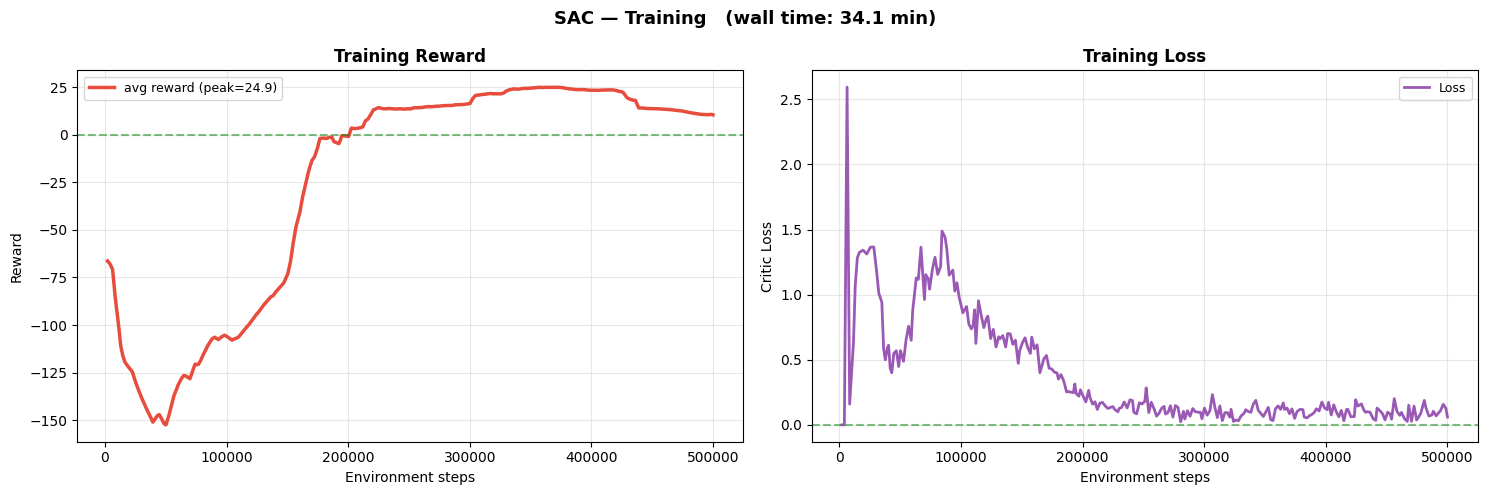

Saved: sac_loss_reward.png
Training (wall) time: 34.1 min  (2046 s)


In [ ]:
plot_loss_reward(logger=logger, algo="SAC")

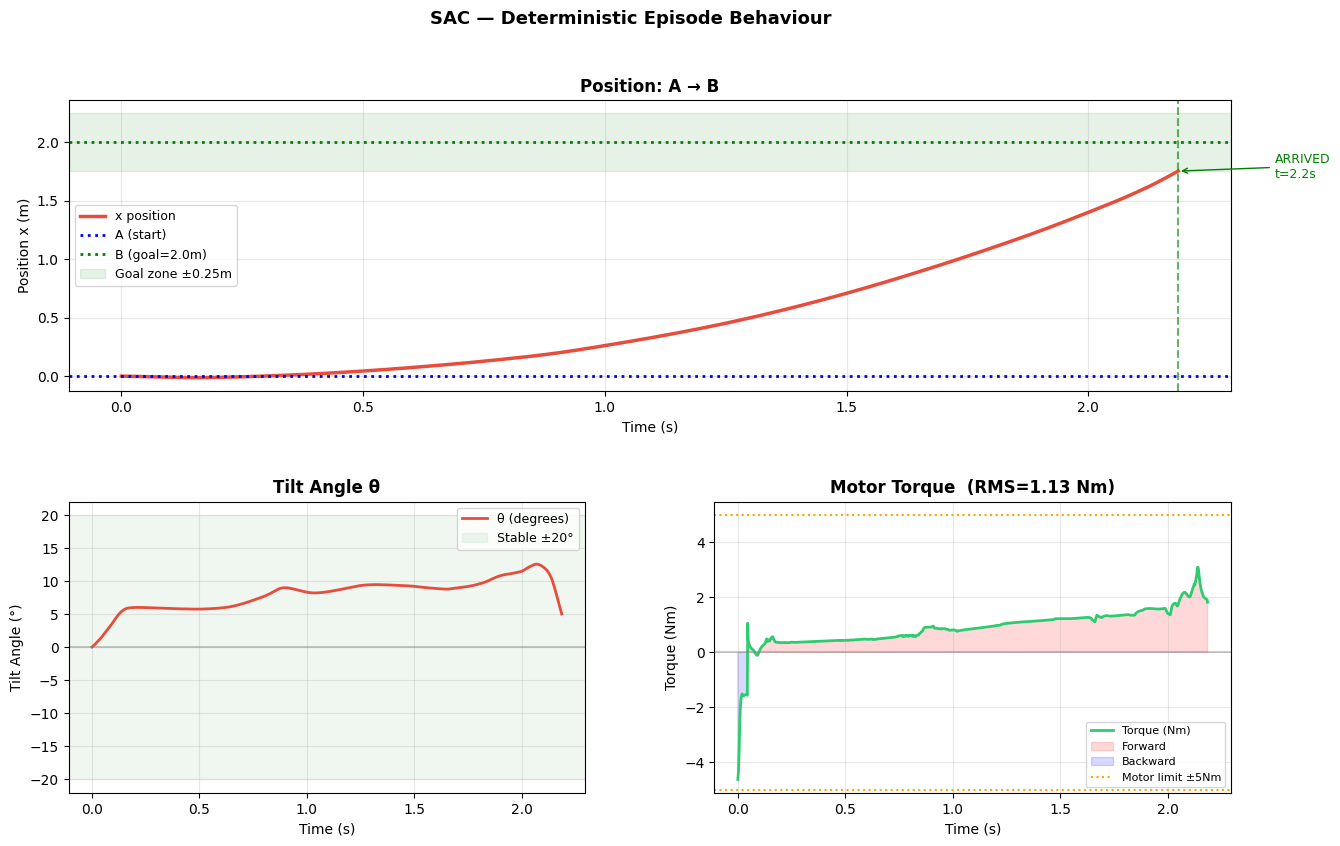

Saved: sac_episode_traces.png

  SAC Episode Summary
  Duration   : 2.2s  (1094 steps)
  Max x      : 1.753m  / 2.0m
  Final x    : 1.753m
  Avg tilt   : 8.0°
  Max tilt   : 12.5°
  Torque RMS : 1.134 Nm
  Saturated  : 0 / 1094 steps (0%)


{'max_x': 1.7528702020645142,
 'final_x': 1.7528702020645142,
 'avg_tilt': 7.976876735687256,
 'torque_rms': 1.1343187593335091,
 'arrived': True,
 'duration_s': 2.186}

In [ ]:
plot_episode_traces(net, algo="SAC")